# Analysis

In [46]:
import numpy as np
import matplotlib.pyplot as plt

## Data

In [47]:
from src.data_prep import get_smiles_df

smiles_df = get_smiles_df()
print(smiles_df['target'].describe())

count    13131.000000
mean       701.367624
std        728.866756
min          0.000000
25%        564.495000
50%        636.040000
75%        718.860000
max      21482.800000
Name: target, dtype: float64


/Users/travisholt/github/trvslhlt/ift_6390_machine_learning/assignments/assignment_2/src/data_prep.py:56: DtypeWarning: Columns (0,6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(URL)


<details>
<summary>Head lines from <code>chedl_thermo_properties.csv</code></summary>
<pre>
CAS,Tc,Pc,Vc,Zc,SMILES,Chemical,omega,Tc_error,Pc_error,Vc_error,ID,name,Tt,Pt,Tb,MW,Reference,Tm,Hfs,Hfl,Hfg,S0s,S0l,S0g,Hsub,Hfus,Hvap,AntoineTmin,AntoineTmax,AntoineA,AntoineB,AntoineC
675-62-7,561.7,2525000.0,0.000488,0.2638411890397846,C[Si](Cl)(Cl)CCC(F)(F)F,,,,,,,,,,,,,,,,,,,,,,,,,,,
2897-60-1,698.7,1598000.0,0.000865,0.2379402722268626,CCO[Si](C)(CCCOCC1CO1)OCC,,,,,,,,,,,,,,,,,,,,,,,,,,,
7351-61-3,708.1,2113000.0,0.000664,0.2383080960885552,CC(=C)C(=O)OCCC[Si](Cl)(Cl)Cl,,,,,,,,,,,,,,,,,,,,,,,,,,,
2530-83-8,701.4,1812000.0,0.000732,0.2274412993598391,CO[Si](CCCOCC1CO1)(OC)OC,,,,,,,,,,,,,,,,,,,,,,,,,,,
</pre>
</details>

<details>
<summary>Column names and data types</summary>
<pre>
CAS              object   — CAS registry number (identifier)
Tc               float64  — Critical temperature (K)
Pc               float64  — Critical pressure (Pa)
Vc               float64  — Critical volume (m³/mol)
Zc               float64  — Critical compressibility factor
SMILES           object   — SMILES molecular representation
Chemical         object   — Chemical name
omega            float64  — Acentric factor
Tc_error         float64  — Tc measurement error
Pc_error         float64  — Pc measurement error
Vc_error         float64  — Vc measurement error
ID               float64  — Identifier
name             object   — Compound name
Tt               float64  — Triple point temperature (K)
Pt               float64  — Triple point pressure (Pa)
Tb               float64  — Boiling point (K)
MW               float64  — Molecular weight (g/mol)
Reference        object   — Data source reference
Tm               float64  — Melting point (K)
Hfs              float64  — Std. enthalpy of formation, solid (J/mol)
Hfl              float64  — Std. enthalpy of formation, liquid (J/mol)
Hfg              float64  — Std. enthalpy of formation, gas (J/mol)
S0s              float64  — Std. entropy, solid (J/mol·K)
S0l              float64  — Std. entropy, liquid (J/mol·K)
S0g              float64  — Std. entropy, gas (J/mol·K)
Hsub             float64  — Enthalpy of sublimation (J/mol)
Hfus             float64  — Enthalpy of fusion (J/mol)
Hvap             float64  — Enthalpy of vaporization (J/mol)
AntoineTmin      float64  — Antoine equation min temperature (K)
AntoineTmax      float64  — Antoine equation max temperature (K)
AntoineA         float64  — Antoine coefficient A
AntoineB         float64  — Antoine coefficient B
AntoineC         float64  — Antoine coefficient C
</pre>
</details>

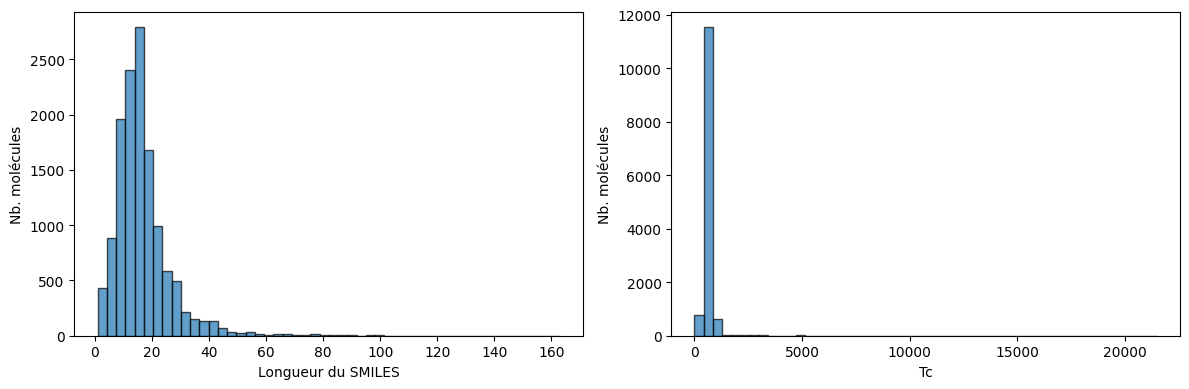

Vocabulaire (60 caractères) : #()+-./123457=@ABCDEFGHIKLMNOPRSTUVWXYZ[\]abcdefghilmnorstuy
Longueur : min=1, max=163, moy=17


In [48]:
df = smiles_df
smiles_lengths = [len(s) for s in df["smiles"]]
unique_chars = sorted(set("".join(df["smiles"])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(smiles_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Longueur du SMILES")
axes[0].set_ylabel("Nb. molécules")
axes[1].hist(df["target"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel('Tc') # sample label property
axes[1].set_ylabel("Nb. molécules")
plt.tight_layout()
plt.show()

print(f"Vocabulaire ({len(unique_chars)} caractères) : {''.join(unique_chars)}")
print(f"Longueur : min={min(smiles_lengths)}, max={max(smiles_lengths)}, moy={np.mean(smiles_lengths):.0f}")

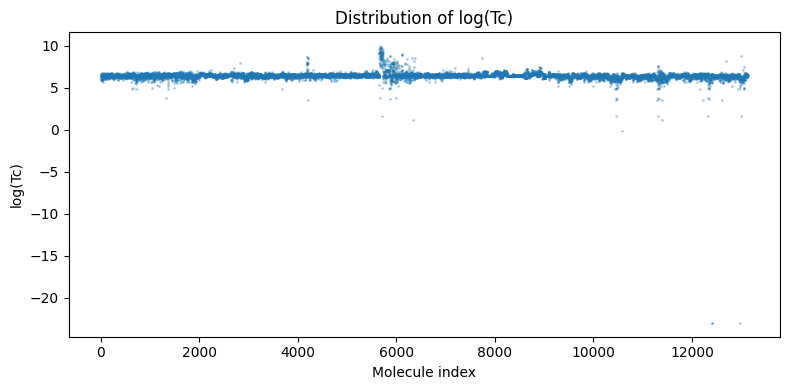

In [42]:
df = smiles_df
log_tc = np.log(np.clip(df["target"], a_min=1e-10, a_max=None))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(len(log_tc)), log_tc, s=1, alpha=0.3)
ax.set_xlabel("Molecule index")
ax.set_ylabel("log(Tc)")
ax.set_title("Distribution of log(Tc)")
plt.tight_layout()
plt.show()

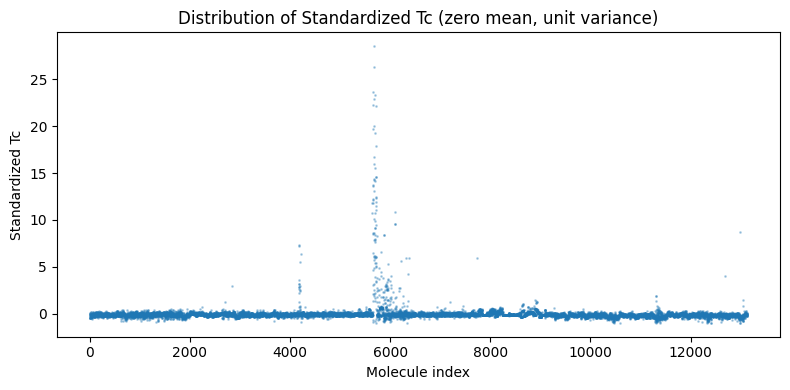

In [43]:
tc_standardized = (df["target"] - df["target"].mean()) / df["target"].std()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(len(tc_standardized)), tc_standardized, s=1, alpha=0.3)
ax.set_xlabel("Molecule index")
ax.set_ylabel("Standardized Tc")
ax.set_title("Distribution of Standardized Tc (zero mean, unit variance)")
plt.tight_layout()
plt.show()

## 1

### 1.1

log_file=PosixPath('logs/exp_1_1__2026_03_27__14_53_09.json')


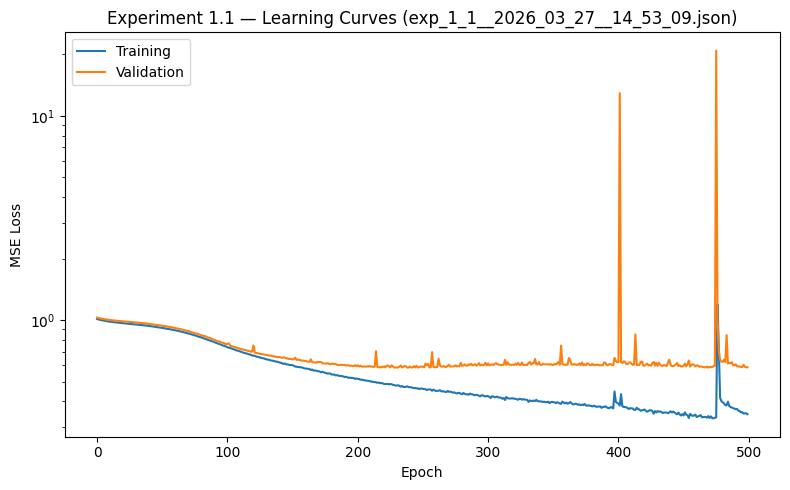

In [44]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

log_file = sorted(Path("logs").glob("exp_1_1__*.json"))[-1]
print(f'{log_file=}')

with open(log_file) as f:
    logs = json.load(f)

epochs = [e["epoch"] for e in logs["epoch"]]
train_loss = [e["train_loss"] for e in logs["epoch"]]
val_loss = [e["val_loss"] for e in logs["epoch"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_loss, label="Training")
ax.plot(epochs, val_loss, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_yscale("log")
ax.set_title(f"Experiment 1.1 — Learning Curves ({log_file.name})")
ax.legend()
plt.tight_layout()
plt.show()

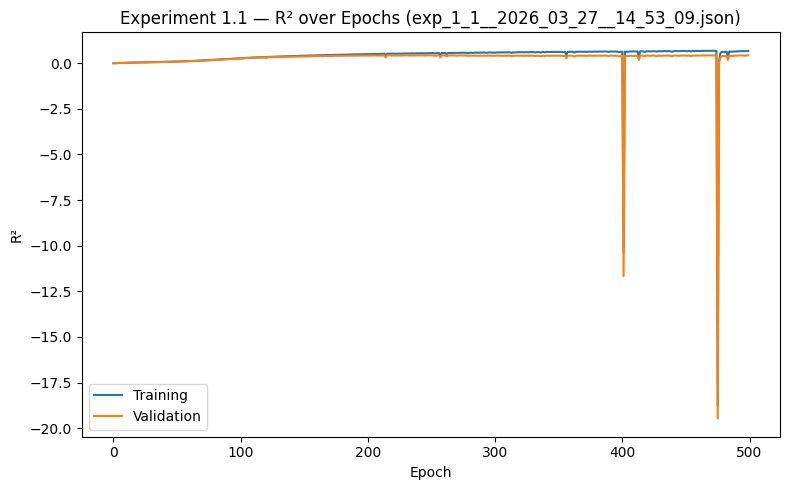

In [45]:
epochs = [e["epoch"] for e in logs["epoch"]]
train_r2 = [e["train_r2"] for e in logs["epoch"]]
val_r2 = [e["val_r2"] for e in logs["epoch"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_r2, label="Training")
ax.plot(epochs, val_r2, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("R²")
ax.set_title(f"Experiment 1.1 — R² over Epochs ({log_file.name})")
ax.legend()
plt.tight_layout()
plt.show()